In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

In [14]:
ipl = pd.read_csv("IPL.csv")

print("First 10 Records:\n")
print(ipl.head(10))

C:\Users\Arunangshu Dasgupta\AppData\Local\Temp\ipykernel_71456\177138371.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  ipl = pd.read_csv("IPL.csv")


First 10 Records:

   Unnamed: 0  match_id        date match_type             event_name  \
0      131970    335982  2008-04-18        T20  Indian Premier League   
1      131971    335982  2008-04-18        T20  Indian Premier League   
2      131972    335982  2008-04-18        T20  Indian Premier League   
3      131973    335982  2008-04-18        T20  Indian Premier League   
4      131974    335982  2008-04-18        T20  Indian Premier League   
5      131975    335982  2008-04-18        T20  Indian Premier League   
6      131976    335982  2008-04-18        T20  Indian Premier League   
7      131977    335982  2008-04-18        T20  Indian Premier League   
8      131978    335982  2008-04-18        T20  Indian Premier League   
9      131979    335982  2008-04-18        T20  Indian Premier League   

   innings           batting_team                 bowling_team  over  ball  \
0        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     1   
1        1  Kolkata K

In [15]:
season_col = [col for col in ipl.columns if 'season' in col.lower()][0]

team_cols = [col for col in ipl.columns if 'team' in col.lower()]

winner_cols = [col for col in ipl.columns if 'winner' in col.lower()]
winner_col = winner_cols[0] if winner_cols else None

venue_col = [col for col in ipl.columns if 'venue' in col.lower()]
venue_col = venue_col[0] if venue_col else None

In [16]:
ipl[season_col] = pd.to_numeric(ipl[season_col], errors='coerce')
ipl = ipl.dropna(subset=[season_col])

In [17]:
total_matches = len(ipl)

teams = pd.unique(ipl[team_cols].values.ravel())
total_teams = len(teams)

total_seasons = ipl[season_col].nunique()

print("\n--- COUNT SUMMARY ---")
print("Total Matches:", total_matches)
print("Total Teams:", total_teams)
print("Total Seasons:", total_seasons)


--- COUNT SUMMARY ---
Total Matches: 235659
Total Teams: 304
Total Seasons: 15


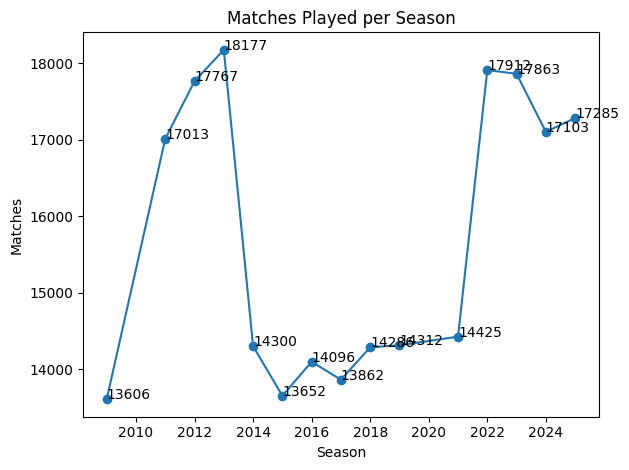

In [18]:
matches_per_season = ipl[season_col].value_counts().sort_index()

plt.figure()
plt.plot(matches_per_season.index, matches_per_season.values, marker='o')

plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Matches")

for x, y in zip(matches_per_season.index, matches_per_season.values):
    plt.text(x, y, str(y))

plt.tight_layout()
plt.show()

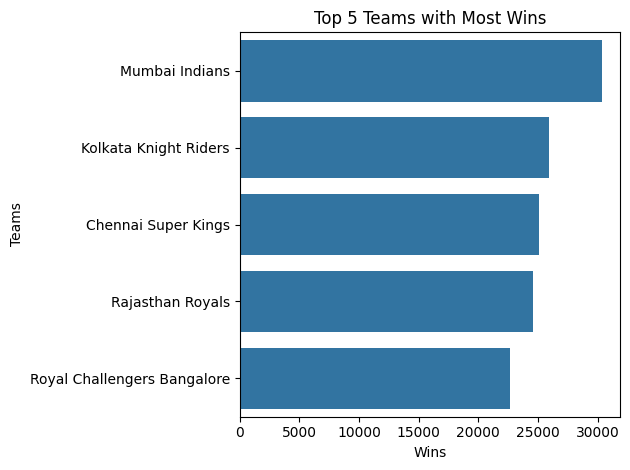

In [19]:
if winner_col:
    top_teams = ipl[winner_col].value_counts().head(5)

    plt.figure()
    sns.barplot(x=top_teams.values, y=top_teams.index)

    plt.title("Top 5 Teams with Most Wins")
    plt.xlabel("Wins")
    plt.ylabel("Teams")

    plt.tight_layout()
    plt.show()

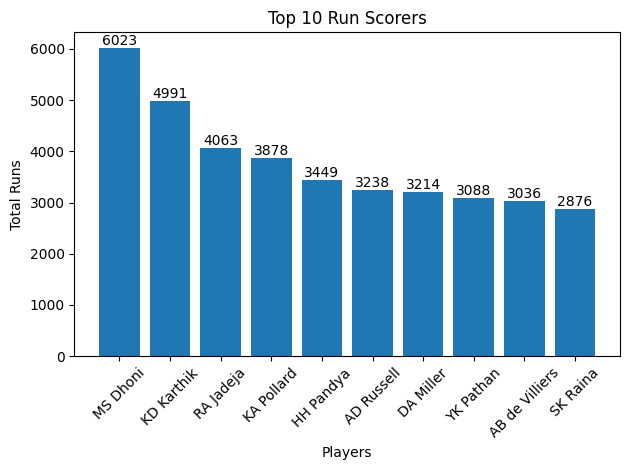

In [20]:
batsman_col = None
runs_col = None

for col in ipl.columns:
    if 'batsman' in col.lower() or 'batter' in col.lower():
        batsman_col = col
    if 'run' in col.lower():
        runs_col = col

if batsman_col and runs_col:

    ipl[runs_col] = pd.to_numeric(ipl[runs_col], errors='coerce').fillna(0)

    top_scorers = (
        ipl.groupby(batsman_col)[runs_col]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure()
    bars = plt.bar(top_scorers.index, top_scorers.values)

    plt.title("Top 10 Run Scorers")
    plt.xlabel("Players")
    plt.ylabel("Total Runs")
    plt.xticks(rotation=45)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h,
                 str(int(h)), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

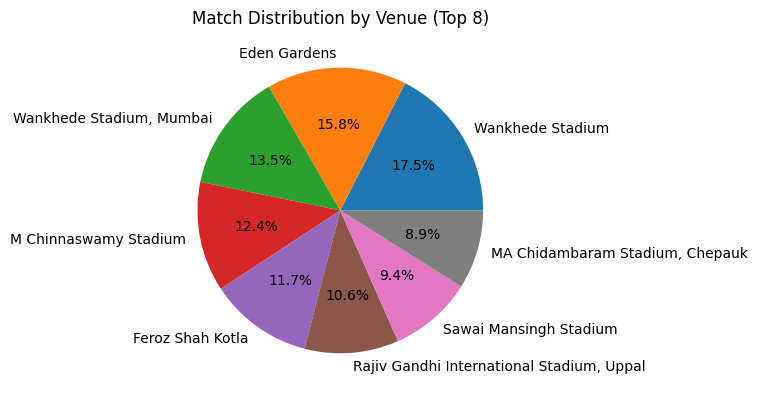

In [21]:
if venue_col:
    venue_counts = ipl[venue_col].value_counts().head(8)

    plt.figure()
    plt.pie(venue_counts.values,
            labels=venue_counts.index,
            autopct='%1.1f%%')

    plt.title("Match Distribution by Venue (Top 8)")
    plt.tight_layout()
    plt.show()

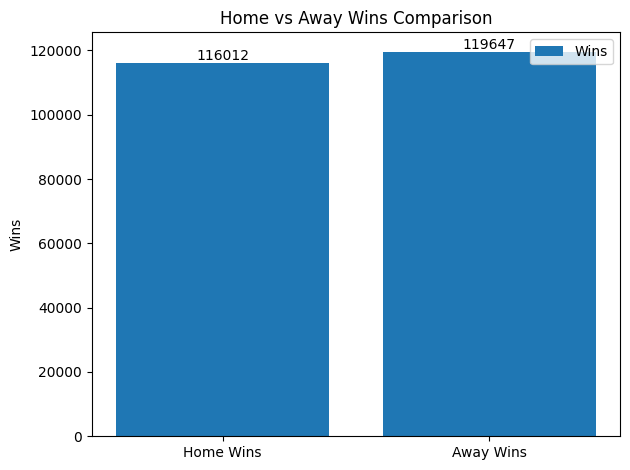

In [22]:
if len(team_cols) >= 2 and winner_col:
    team1_col = team_cols[0]
    team2_col = team_cols[1]

    home_wins = ipl[ipl[team1_col] == ipl[winner_col]].shape[0]
    away_wins = ipl[ipl[team2_col] == ipl[winner_col]].shape[0]

    plt.figure()
    bars = plt.bar(['Home Wins', 'Away Wins'], [home_wins, away_wins])

    plt.title("Home vs Away Wins Comparison")
    plt.ylabel("Wins")

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, str(h),
                 ha='center', va='bottom')

    plt.legend(['Wins'])
    plt.tight_layout()
    plt.show()

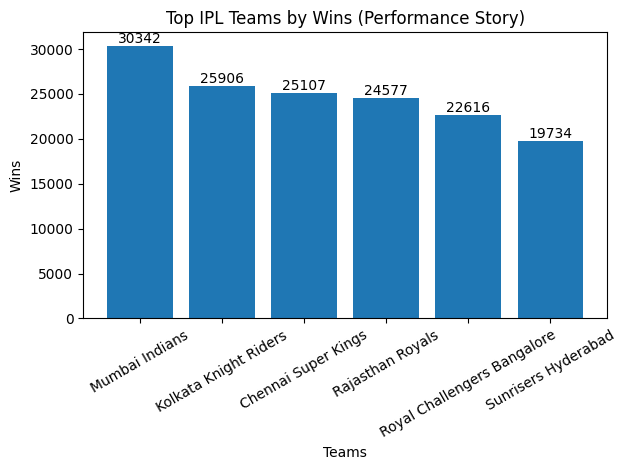

In [23]:
if winner_col:
    team_wins = ipl[winner_col].value_counts().head(6)

    plt.figure()
    bars = plt.bar(team_wins.index, team_wins.values)

    plt.title("Top IPL Teams by Wins (Performance Story)")
    plt.xlabel("Teams")
    plt.ylabel("Wins")
    plt.xticks(rotation=30)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h, str(h),
                 ha='center', va='bottom')

    plt.tight_layout()
    plt.show()